#Cryptocurrency Volatility Prediction Project

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')

In **import libraries**
We use these tools for data handling, plots, ML model saving/loading

In [2]:
#Load dataset

df = pd.read_csv('dataset.csv')


In **load dataset** reading historical crypto data from CSV and Data comes into a Pandas DataFrame

In [3]:
df.head() #-> this tells about columns

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [4]:
df.shape #rows and colums present in dataset

(72946, 10)

In [5]:
df.info() #its tells about the datatype of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [6]:
#Convert date columns
df['date'] = pd.to_datetime(df['date'])


In [7]:
#Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

Convert of **date & timestamp** because its used for rolling calculations and time-base analysis without this volatility will be wrong

In [8]:
#Sort data
df = df.sort_values(by=['crypto_name','date'])

#Grouping each crypto, Orders records from oldest -> newest
#Rolling volatility depends on correct time order

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72946 entries, 44644 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Unnamed: 0   72946 non-null  int64              
 1   open         72946 non-null  float64            
 2   high         72946 non-null  float64            
 3   low          72946 non-null  float64            
 4   close        72946 non-null  float64            
 5   volume       72946 non-null  float64            
 6   marketCap    72946 non-null  float64            
 7   timestamp    72946 non-null  datetime64[ns, UTC]
 8   crypto_name  72946 non-null  object             
 9   date         72946 non-null  datetime64[ns]     
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 6.1+ MB


In [10]:
df.describe() #Basic data understanding

,Unnamed: 0,open,high,low,close,volume,marketCap,date
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04,72946
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10,2019-10-13 03:20:59.945713152
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00,2013-05-05 00:00:00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08,2018-09-08 00:00:00
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09,2020-03-17 00:00:00
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09,2021-05-02 00:00:00
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12,2022-10-23 00:00:00
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10,NaN


In [11]:
#Create daily returns
df['daily_return'] = df.groupby('crypto_name')['close'].pct_change()

#Measures day-today price change
#Volatility is based on return, not prices

In [12]:
# Create target variable

df['volatility_7d_x'] = df.groupby('crypto_name')['daily_return'].rolling(7).std().values

#this calculates 7-day rolling standard deviation and this is what the model will predict
#target variable create here

In [13]:
#Create price-base features
df['hl_spread'] = (df['high']-df['low'])/df['close']
df['oc_change'] = (df['close']-df['open'])/df['open']

#Captures intraday price instablility and
#strong indicator of volatility

In [14]:
#Create liquidity feature

df['liquidity_ratio'] = df['volume']/df['marketCap']

#High volume relative to marketcap
#often leads to high volatility


In [15]:
#Moving averages
df['ma_7'] =(df.groupby('crypto_name')['close'].rolling(window=7).mean().reset_index(level=0, drop=True))
df['ma_14'] =(df.groupby('crypto_name')['close'].rolling(window=14).mean().reset_index(level=0, drop=True))

#Shows short-term and medium-term trends
#Smooths noisy price movement

In [16]:
#Remove missing values
df.dropna(inplace=True)

#Rolling calculations create NaNS
#ML models cannot handel NaNs

In [17]:
#Exploratory Data Analysis(EDA)

df_btc = df[df['crypto_name'] == 'Bitcoin']

#Bitcoin is stable , most liquid, easier to interpret

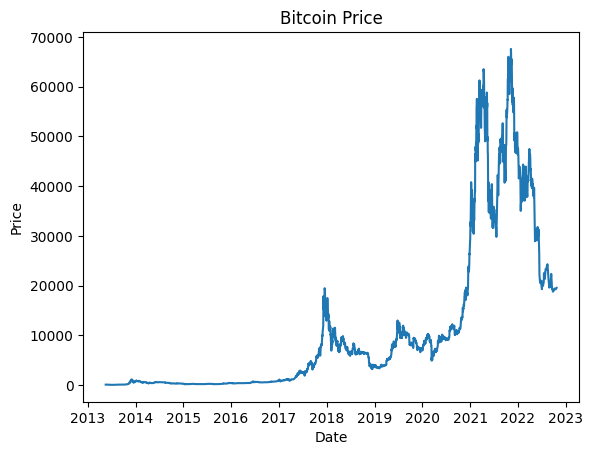

In [18]:
#Price plot
plt.plot(df_btc['date'],df_btc['close'])
plt.title('Bitcoin Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [19]:
#this graph shows price movement

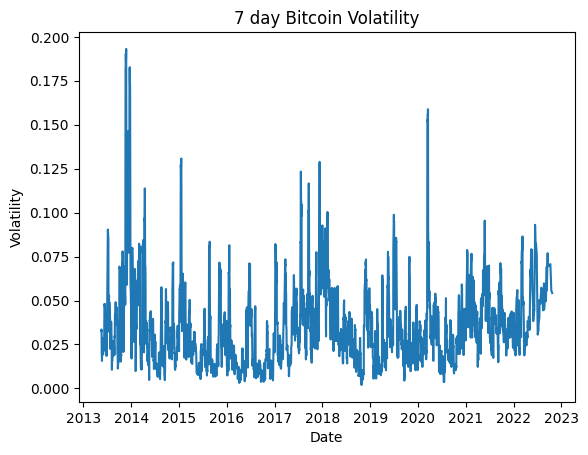

In [20]:
#Volatility plot
plt.plot(df_btc['date'],df_btc['volatility_7d_x'])
plt.title('7 day Bitcoin Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


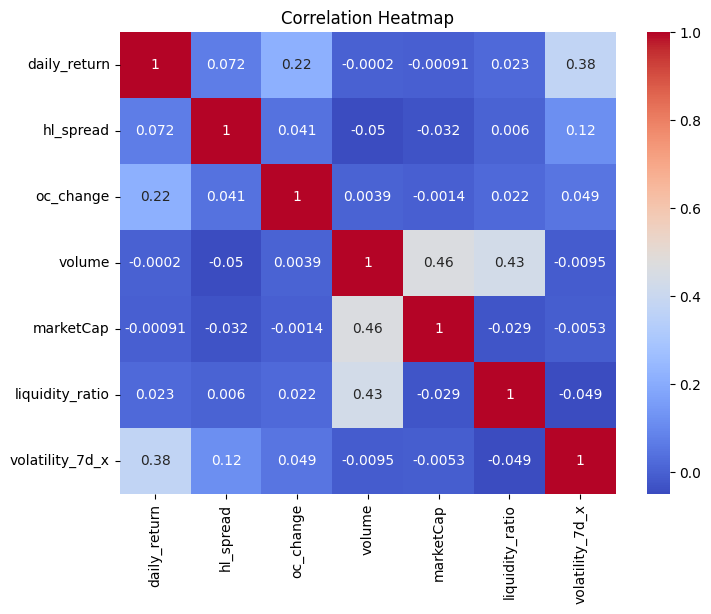

In [21]:
#Correlation heatmap
features = ['daily_return','hl_spread','oc_change','volume','marketCap','liquidity_ratio','volatility_7d_x']
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Shows relation between features and volatilty


In [22]:
#Prepare data for model
features = ['daily_return', 'hl_spread', 'oc_change', 'volume', 'marketCap', 'liquidity_ratio']

X = df[features]
y = df['volatility_7d_x']

In [23]:
#Time-based train-test split
split_index = int(len(df)*0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Handle Infinite Values and NaNs

Before applying the `StandardScaler` or training the model, it's crucial to handle infinite values which caused the previous error. We'll convert infinite values to `NaN` and then remove any rows containing `NaN` to ensure clean datasets for scaling and model training.

In [24]:
# Replace infinite values with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
y_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
y_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Combine X_train and y_train for aligned dropping of NaNs
train_data = pd.concat([X_train, y_train], axis=1)
train_data.dropna(inplace=True)
X_train = train_data[X_train.columns]
y_train = train_data[y_train.name]

# Combine X_test and y_test for aligned dropping of NaNs
test_data = pd.concat([X_test, y_test], axis=1)
test_data.dropna(inplace=True)
X_test = test_data[X_test.columns]
y_test = test_data[y_test.name]

print(f"X_train shape after cleaning: {X_train.shape}")
print(f"y_train shape after cleaning: {y_train.shape}")
print(f"X_test shape after cleaning: {X_test.shape}")
print(f"y_test shape after cleaning: {y_test.shape}")

X_train shape after cleaning: (55970, 6)
y_train shape after cleaning: (55970,)
X_test shape after cleaning: (14147, 6)
y_test shape after cleaning: (14147,)


### Apply StandardScaler

Now that the data is clean, we can apply `StandardScaler` to `X_train` and `X_test`. This will standardize features by removing the mean and scaling to unit variance.

In [25]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames with original column names for better readability
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train and X_test have been scaled successfully.")
display(X_train.head())

X_train and X_test have been scaled successfully.


,daily_return,hl_spread,oc_change,volume,marketCap,liquidity_ratio
45270,-1.670094,0.741025,-1.937483,-0.265795,-0.200495,-0.460451
45325,-1.220219,0.260364,-1.094955,-0.258134,-0.198809,-0.133422
45398,0.492116,0.158979,0.567824,-0.259686,-0.198606,-0.220375
45457,-0.219170,-0.248290,-0.260517,-0.260159,-0.198673,-0.236892
45502,-1.373486,0.409799,-1.606327,-0.258715,-0.199188,-0.124310


In [26]:
# RandomForest model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [28]:
#Evaluate model
y_pred = rf.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.0011653738371918971
Mean Absolute Error: 0.020324183193605523
R-squared: 0.46153187245167415


In [30]:
rf.feature_importances_

array([0.147477  , 0.36735421, 0.11527648, 0.16510587, 0.10079734,
       0.10398911])

In [31]:
#Save model
joblib.dump(rf, 'rf_model.pkl')


['rf_model.pkl']

In [32]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']